# Full Process Lens For This Project

Use this section every time you start a project so you practice the same end-to-end workflow, not just isolated coding tasks.

## 1) Data Transformation and Processing (What and Why)

Raw data is rarely model-ready. Your first job is to transform data into a reliable, learnable format.

What to do in every project:
- Identify data types and expected schema.
- Handle missing values, duplicates, and inconsistent formats.
- Convert features into model-usable representations (encoding, scaling, tokenization, chunking, etc.).
- Keep transformations reproducible so train and inference use the same logic.
- Document assumptions and risks introduced by preprocessing choices.

Why this matters:
- Better preprocessing usually improves results more than switching algorithms.
- Poor preprocessing creates hidden errors that look like model failure.

## 2) Evaluating and Improving Models (What and Why)

Evaluation is not the last step. It is the loop that drives improvement.

What to do in every project:
- Start with a baseline and compare against it.
- Choose metrics tied to the real goal (not just convenience metrics).
- Inspect errors by slice (segments, classes, edge cases).
- Tune thresholds, features, prompts, retrieval settings, or hyperparameters based on evidence.
- Re-evaluate after each change and keep track of what improved and what regressed.

Why this matters:
- A model can appear good overall but fail on important cases.
- Iterative evaluation is how projects become production-ready, not just demo-ready.

## 3) Project Reflection Checklist

Before marking this project complete, confirm:
- I can explain how data was transformed and why.
- I can explain which metrics I chose and why.
- I can show at least one improvement cycle from evaluation findings.
- I can describe current limitations and next improvements.

In [2]:
# First run check (beginner safe)
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print('Python version:', sys.version.split()[0])
print('NumPy version:', np.__version__)
print('pandas version:', pd.__version__)
print('Setup check passed. You can continue.')

Python version: 3.9.6
NumPy version: 2.0.2
pandas version: 2.3.3
Setup check passed. You can continue.


# Beginner Start Here (Weeks 6-7: House Price)

You can complete this notebook even if regression is new to you.

## What is regression?
Regression predicts a number, not a category. Here we predict price.

## Modules used in this notebook
- `pandas`: reading and cleaning housing data.
- `numpy`: numerical operations.
- `sklearn`: regression models (Linear, Ridge, Lasso, etc.).
- `matplotlib`/`seaborn`: data and residual plots.

## Key terms
- Regression: prediction of continuous values.
- RMSE: average prediction error size (lower is better).
- R2 score: how much variance the model explains (higher is better).
- Residual: `actual - predicted`.
- Overfitting: model memorizes training data but fails on new data.

## How to work through this notebook
1. Understand data columns first.
2. Train baseline model before advanced ones.
3. Compare models with the same test split.
4. Explain results in plain language at each step.

# Weeks 6-7: House Price Prediction

## Overview
Predict house prices using regression models. Quantify the relationship between features and price.

**Learning Goals:**
- Regression (predicting continuous values)
- Handle numerical and categorical features
- Model evaluation for regression
- Feature engineering
- Residual analysis

**Time:** 8-12 hours across 2 weeks

**Difficulty:** 🟡 Combine foundations + new concepts

---

## Challenge Summary
12 challenges to build a complete regression pipeline and predict house prices.

## Challenge 1: Load Housing Data

**Goal:** Load and examine house price dataset.

**Steps:**
1. Load housing dataset (Boston Housing, California Housing, or Kaggle)
2. Display dataset shape, columns, types
3. Show first 5 rows
4. Print column meanings
5. Identify target variable (price)

**Expected:**
- 100+ rows with 10+ features
- Target variable: Price (continuous values)
- Features: Square footage, bedrooms, bathrooms, neighborhood, etc.

In [3]:
from sklearn.datasets import fetch_california_housing
df = fetch_california_housing(as_frame=True).frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.shape

(20640, 9)

In [5]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Challenge 2: Exploratory Analysis

**Goal:** Understand price distribution and feature relationships.

**Steps:**
1. Describe numerical features (mean, std, min, max)
2. Plot price distribution (histogram)
3. Check for skewness (is distribution normal?)
4. Identify missing values
5. Show summary statistics

**Expected insights:**
- Price distribution shape (symmetric? skewed?)
- Data completeness
- Outliers present?

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isna().sum(),df.isnull().sum()

(MedInc         0
 HouseAge       0
 AveRooms       0
 AveBedrms      0
 Population     0
 AveOccup       0
 Latitude       0
 Longitude      0
 MedHouseVal    0
 dtype: int64,
 MedInc         0
 HouseAge       0
 AveRooms       0
 AveBedrms      0
 Population     0
 AveOccup       0
 Latitude       0
 Longitude      0
 MedHouseVal    0
 dtype: int64)

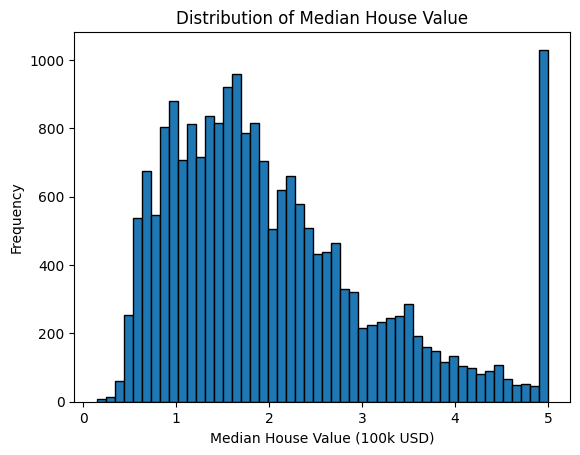

In [9]:
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value (100k USD)')
plt.ylabel('Frequency')
plt.show()

***data has no missing values, so we can proceed without needing to handle missing data.***

## Pre-Training Learning Checkpoint (Before Visualization)

Complete this teaching checkpoint before starting visualization and model training.

Use Phase 0 as your reference:
- guides/phase0/GUIDE_Week2_PandasDeep.md
- guides/phase0/GUIDE_Week3_NumPyDeep.md
- guides/phase0/GUIDE_Week4_Visualization.md
- docs/AI-ML-LEARNING-GUIDE.md (Phase 0 and Phase 1 sections)

Questions to answer in markdown before moving on:
1. What data quality issues exist (missing values, wrong types, duplicates, outliers)?
2. What needs to be transformed before training, and why?
3. Is the target variable clearly defined and consistently encoded?
4. What preprocessing choices could change model behavior?
5. What baseline will you compare against after training?

Done criteria:
- You can explain your data fixing and preparation plan in plain language.
- You can justify preprocessing decisions before training begins.
- You are ready to visualize with a clean data strategy.

## Challenge 3: Visualize Feature Relationships

**Goal:** Understand which features correlate with price.

**Steps:**
1. Create correlation matrix (only numerical features)
2. Visualize as heatmap (seaborn)
3. Identify features most correlated with price
4. Create scatter plots for top 3-4 features vs price
5. Label axes clearly

**Expected:**
- Some features strongly correlated with price
- Clear linear/non-linear patterns visible

<Axes: >

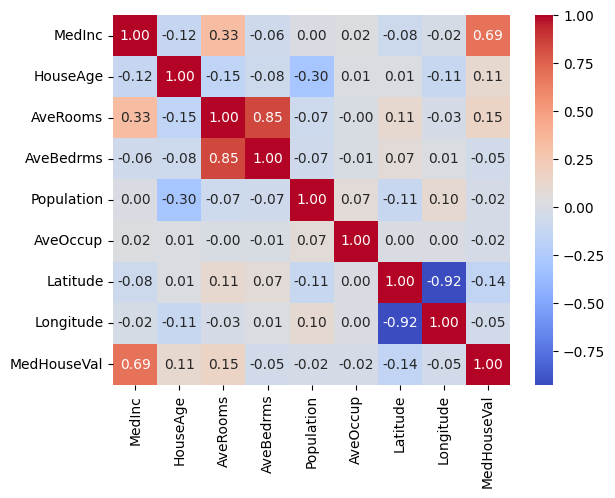

In [10]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

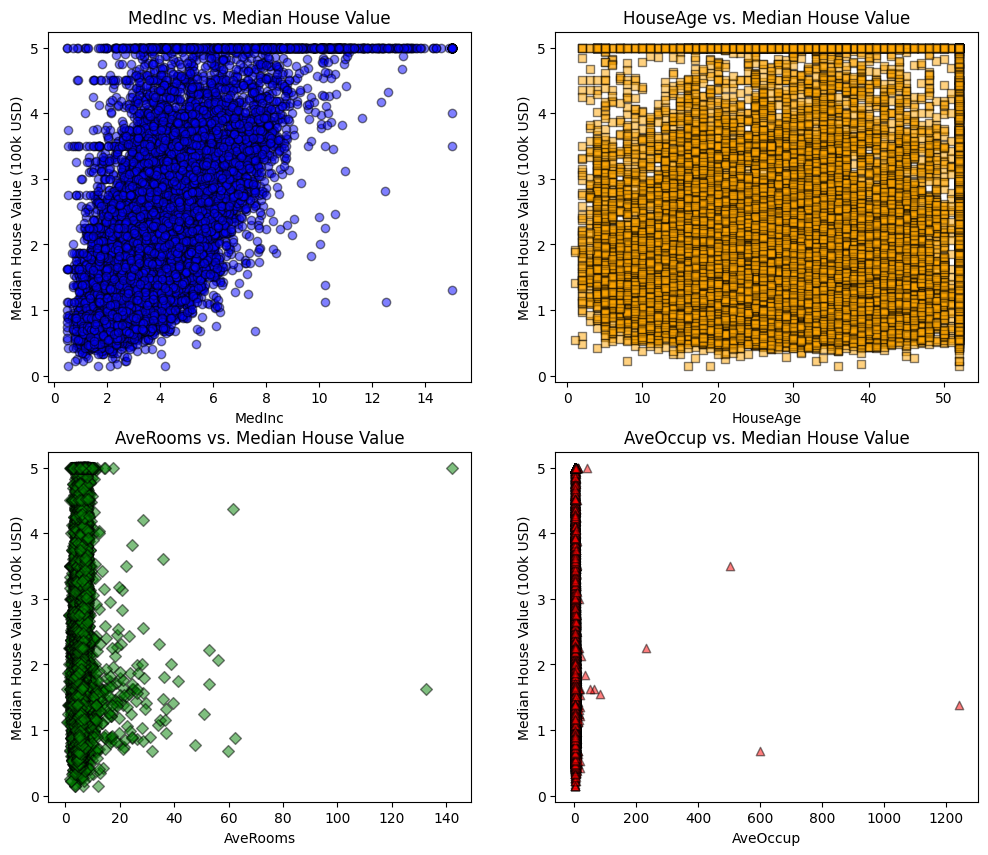

In [11]:
fig,ax = plt.subplots(2,2,figsize=(12,10))
ax1=ax[0,0]
ax2=ax[0,1]
ax3=ax[1,0]
ax4=ax[1,1]

ax_arr = [ax1, ax2, ax3, ax4]
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
colors = ['blue', 'orange', 'green', 'red']
markers = ['o', 's', 'D', '^']


for i,features in enumerate(features):
    ax_arr[i].scatter(df[features], df['MedHouseVal'], alpha=0.5, color=colors[i], marker=markers[i], edgecolor='black')
    ax_arr[i].set_title(f'{features} vs. Median House Value')
    ax_arr[i].set_xlabel(features)
    ax_arr[i].set_ylabel('Median House Value (100k USD)')

plt.show()

## Challenge 4: Data Preparation

**Goal:** Prepare data for regression model.

**Steps:**
1. Separate features (X) from target (y)
2. Handle missing values (drop or impute)
3. Encode categorical variables if any
4. Scale ALL features (StandardScaler)
   - Important: fit on train data only
5. Split into train/test (80/20, use random_state=42)

**Expected:**
- X_train: scaled features
- y_train: target prices
- X_test, y_test: holdout set
- No missing values

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [13]:
from sklearn.model_selection import train_test_split

x=df.drop('MedHouseVal', axis=1)
y=df['MedHouseVal']

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), x_train.columns)
])

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

x_train_processed.shape, x_test_processed.shape

((16512, 8), (4128, 8))

## Challenge 5: Train Linear Regression

**Goal:** Create baseline regression model.

**Steps:**
1. Import LinearRegression
2. Create and train model
3. Make predictions on training and test sets
4. Compare actual vs predicted (show first 10)
5. Print model coefficients (what's the impact of each feature?)

**Expected:**
- Model trained without errors
- Predictions are continuous values (not rounded)
- Some predictions match actual values closely

In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(x_train_processed, y_train)

LinearRegression()

In [16]:
lr_model_predictions = lr_model.predict(x_test_processed)

lr_moodel_pred_vs_actual = pd.DataFrame({'Actual': y_test, 'Predicted': lr_model_predictions, "difference": y_test - lr_model_predictions})

lr_moodel_pred_vs_actual.head(10)

,Actual,Predicted,difference
20046,0.47700,0.719123,-0.242123
3024,0.45800,1.764017,-1.306017
15663,5.00001,2.709659,2.290351
20484,2.18600,2.838926,-0.652926
9814,2.78000,2.604657,0.175343
13311,1.58700,2.011754,-0.424754
7113,1.98200,2.645500,-0.663500
7668,1.57500,2.168755,-0.593755
18246,3.40000,2.740746,0.659254
5723,4.46600,3.915615,0.550385


In [17]:
lr_model_feature_importances=pd.DataFrame({'Feature': x_train.columns, 'Coefficient': lr_model.coef_}).sort_values(by='Coefficient', ascending=False)
lr_model_feature_importances.head()

,Feature,Coefficient
0,MedInc,0.854383
3,AveBedrms,0.339259
1,HouseAge,0.122546
4,Population,-0.002308
5,AveOccup,-0.040829


In [18]:
from sklearn.metrics import mean_absolute_error, r2_score,root_mean_squared_error

lr_model_mae=mean_absolute_error(y_test, lr_model_predictions)
lr_model_r2=r2_score(y_test, lr_model_predictions)
lr_model_rmse=root_mean_squared_error(y_test, lr_model_predictions)

print(f"MAE: {lr_model_mae}")
print(f"R2 Score: {lr_model_r2}")
print(f"RMSE: {lr_model_rmse}")

MAE: 0.5332001304956562
R2 Score: 0.575787706032451
RMSE: 0.7455813830127763


## Challenge 6: Train Advanced Models

**Goal:** Compare multiple regression models.

**Steps:**
1. Train 2 additional models:
   - RandomForestRegressor
   - GradientBoostingRegressor
2. For each model:
   - Train on X_train, y_train
   - Make predictions on test set
3. Store predictions for later comparison

**Expected:**
- All models train successfully
- Predictions are realistic prices

In [19]:
from sklearn.ensemble import RandomForestRegressor

rfr_model = RandomForestRegressor(random_state=42)

rfr_model.fit(x_train_processed, y_train)

RandomForestRegressor(random_state=42)

In [20]:
rfr_model_predictions = rfr_model.predict(x_test_processed)

rfr_model_predictions_vs_actual = pd.DataFrame({'Actual': y_test, 'Predicted': rfr_model_predictions, "difference": y_test - rfr_model_predictions})
rfr_model_predictions_vs_actual.head(10)

,Actual,Predicted,difference
20046,0.47700,0.508710,-0.031710
3024,0.45800,0.744040,-0.286040
15663,5.00001,4.915087,0.084923
20484,2.18600,2.527520,-0.341520
9814,2.78000,2.265550,0.514450
13311,1.58700,1.652130,-0.065130
7113,1.98200,2.348090,-0.366090
7668,1.57500,1.663470,-0.088470
18246,3.40000,2.722190,0.677810
5723,4.46600,4.923589,-0.457589


In [21]:
rfr_model_importances = pd.DataFrame({'Feature': x_train.columns, 'Importance': rfr_model.feature_importances_}).sort_values(by='Importance', ascending=False)
rfr_model_importances.head(10)

,Feature,Importance
0,MedInc,0.525037
5,AveOccup,0.138564
6,Latitude,0.088855
7,Longitude,0.088669
1,HouseAge,0.054558
2,AveRooms,0.044195
4,Population,0.030503
3,AveBedrms,0.029620


In [22]:
rfr_model_mae=mean_absolute_error(y_test, rfr_model_predictions)
rfr_model_r2=r2_score(y_test, rfr_model_predictions)
rfr_model_rmse=root_mean_squared_error(y_test, rfr_model_predictions)

print(f"MAE: {rfr_model_mae}")
print(f"R2 Score: {rfr_model_r2}")
print(f"RMSE: {rfr_model_rmse}")

MAE: 0.3275553144622095
R2 Score: 0.8049691880418459
RMSE: 0.5055394416102246


In [23]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(random_state=42)

gbr_model.fit(x_train_processed, y_train)

GradientBoostingRegressor(random_state=42)

In [24]:
gbr_model_predictions = gbr_model.predict(x_test_processed)

gbr_model_predictions_vs_actual = pd.DataFrame({'Actual': y_test, 'Predicted': gbr_model_predictions, "difference": y_test - gbr_model_predictions})
gbr_model_predictions_vs_actual.head(10)

,Actual,Predicted,difference
20046,0.47700,0.505188,-0.028188
3024,0.45800,1.093346,-0.635346
15663,5.00001,4.245710,0.754300
20484,2.18600,2.545174,-0.359174
9814,2.78000,2.279103,0.500897
13311,1.58700,1.723910,-0.136910
7113,1.98200,2.337197,-0.355197
7668,1.57500,1.719774,-0.144774
18246,3.40000,3.099624,0.300376
5723,4.46600,4.304469,0.161531


In [25]:
gbr_model_importances = pd.DataFrame({'Feature': x_train.columns, 'Importance': gbr_model.feature_importances_}).sort_values(by='Importance', ascending=False)
gbr_model_importances.head(10)

,Feature,Importance
0,MedInc,0.604259
5,AveOccup,0.122835
7,Longitude,0.109853
6,Latitude,0.098533
1,HouseAge,0.034113
2,AveRooms,0.023948
3,AveBedrms,0.005106
4,Population,0.001354


In [26]:
gbr_model_mae=mean_absolute_error(y_test, gbr_model_predictions)
gbr_model_r2=r2_score(y_test, gbr_model_predictions)
gbr_model_rmse=root_mean_squared_error(y_test, gbr_model_predictions)

print(f"MAE: {gbr_model_mae}")
print(f"R2 Score: {gbr_model_r2}")
print(f"RMSE: {gbr_model_rmse}")

MAE: 0.37165044848436773
R2 Score: 0.7756433164710084
RMSE: 0.5422167577867202


## Challenge 7: Evaluate Models

**Goal:** Compare model performance using regression metrics.

**Steps:**
1. Import: mean_squared_error, mean_absolute_error, r2_score
2. For each model, calculate:
   - MAE: average absolute error (dollars)
   - MSE: mean squared error
   - RMSE: sqrt(MSE) - standard deviation of errors
   - R²: how much variance explained (0-1)
3. Create comparison table
4. Identify best model

**Expected:**
- RMSE in thousands of dollars (realistic range)
- R² values: closer to 1.0 is better
- Random Forest usually top performer

In [27]:
models=['Linear Regression', 'Random Forest Regressor', 'Gradient Boosting Regressor']
mae=[lr_model_mae, rfr_model_mae, gbr_model_mae]
r2_scores=[lr_model_r2, rfr_model_r2, gbr_model_r2]
rmse=[lr_model_rmse, rfr_model_rmse, gbr_model_rmse]


metrics_df = pd.DataFrame({
    'Model': models,
    'MAE': mae,
    'R2 Score': r2_scores,
    'RMSE': rmse
})
metrics_df

,Model,MAE,R2 Score,RMSE
0,Linear Regression,0.533200,0.575788,0.745581
1,Random Forest Regressor,0.327555,0.804969,0.505539
2,Gradient Boosting Regressor,0.371650,0.775643,0.542217


In [28]:
best_mae_index = metrics_df['MAE'].idxmin()
best_mae_model = metrics_df.loc[best_mae_index, 'Model']
print(f"The model with the best MAE is: {best_mae_model} with an MAE of {metrics_df.loc[best_mae_index, 'MAE']}")

best_r2_index = metrics_df['R2 Score'].idxmax()
best_r2_model = metrics_df.loc[best_r2_index, 'Model']
print(f"The model with the best R2 Score is: {best_r2_model} with an R2 Score of {metrics_df.loc[best_r2_index, 'R2 Score']}")

best_rmse_index = metrics_df['RMSE'].idxmin()
best_rmse_model = metrics_df.loc[best_rmse_index, 'Model']
print(f"The model with the best RMSE is: {best_rmse_model} with an RMSE of {metrics_df.loc[best_rmse_index, 'RMSE']}")

The model with the best MAE is: Random Forest Regressor with an MAE of 0.3275553144622095
The model with the best R2 Score is: Random Forest Regressor with an R2 Score of 0.8049691880418459
The model with the best RMSE is: Random Forest Regressor with an RMSE of 0.5055394416102246


In [29]:
rfr_model.score(x_test_processed, y_test)

0.8049691880418459

The prediction from the early analysis was correct. The best performing model across the 3 models was random forest regressor that could be attributed to the fact that gradient boosting regressor. The other 2 models depended on the the medium income as the primary factor. The random forest regressor had the lowest average absolute error, the lowest means squared error in the lowest are R^2 score.

## Challenge 8: Residual Analysis

**Goal:** Understand prediction errors to improve model.

**Steps:**
1. Calculate residuals: actual - predicted
2. For best model:
   - Plot residuals vs predicted prices (scatter)
   - Plot residuals distribution (histogram)
   - Create Q-Q plot (check normality)
3. Analyze:
   - Are residuals centered at zero?
   - Are errors consistent (homoscedastic)?
   - Are there outliers?

**Expected:**
- Residuals roughly centered at zero
- No clear pattern in scatter plot
- Some outliers likely present

Text(0, 0.5, 'Frequency')

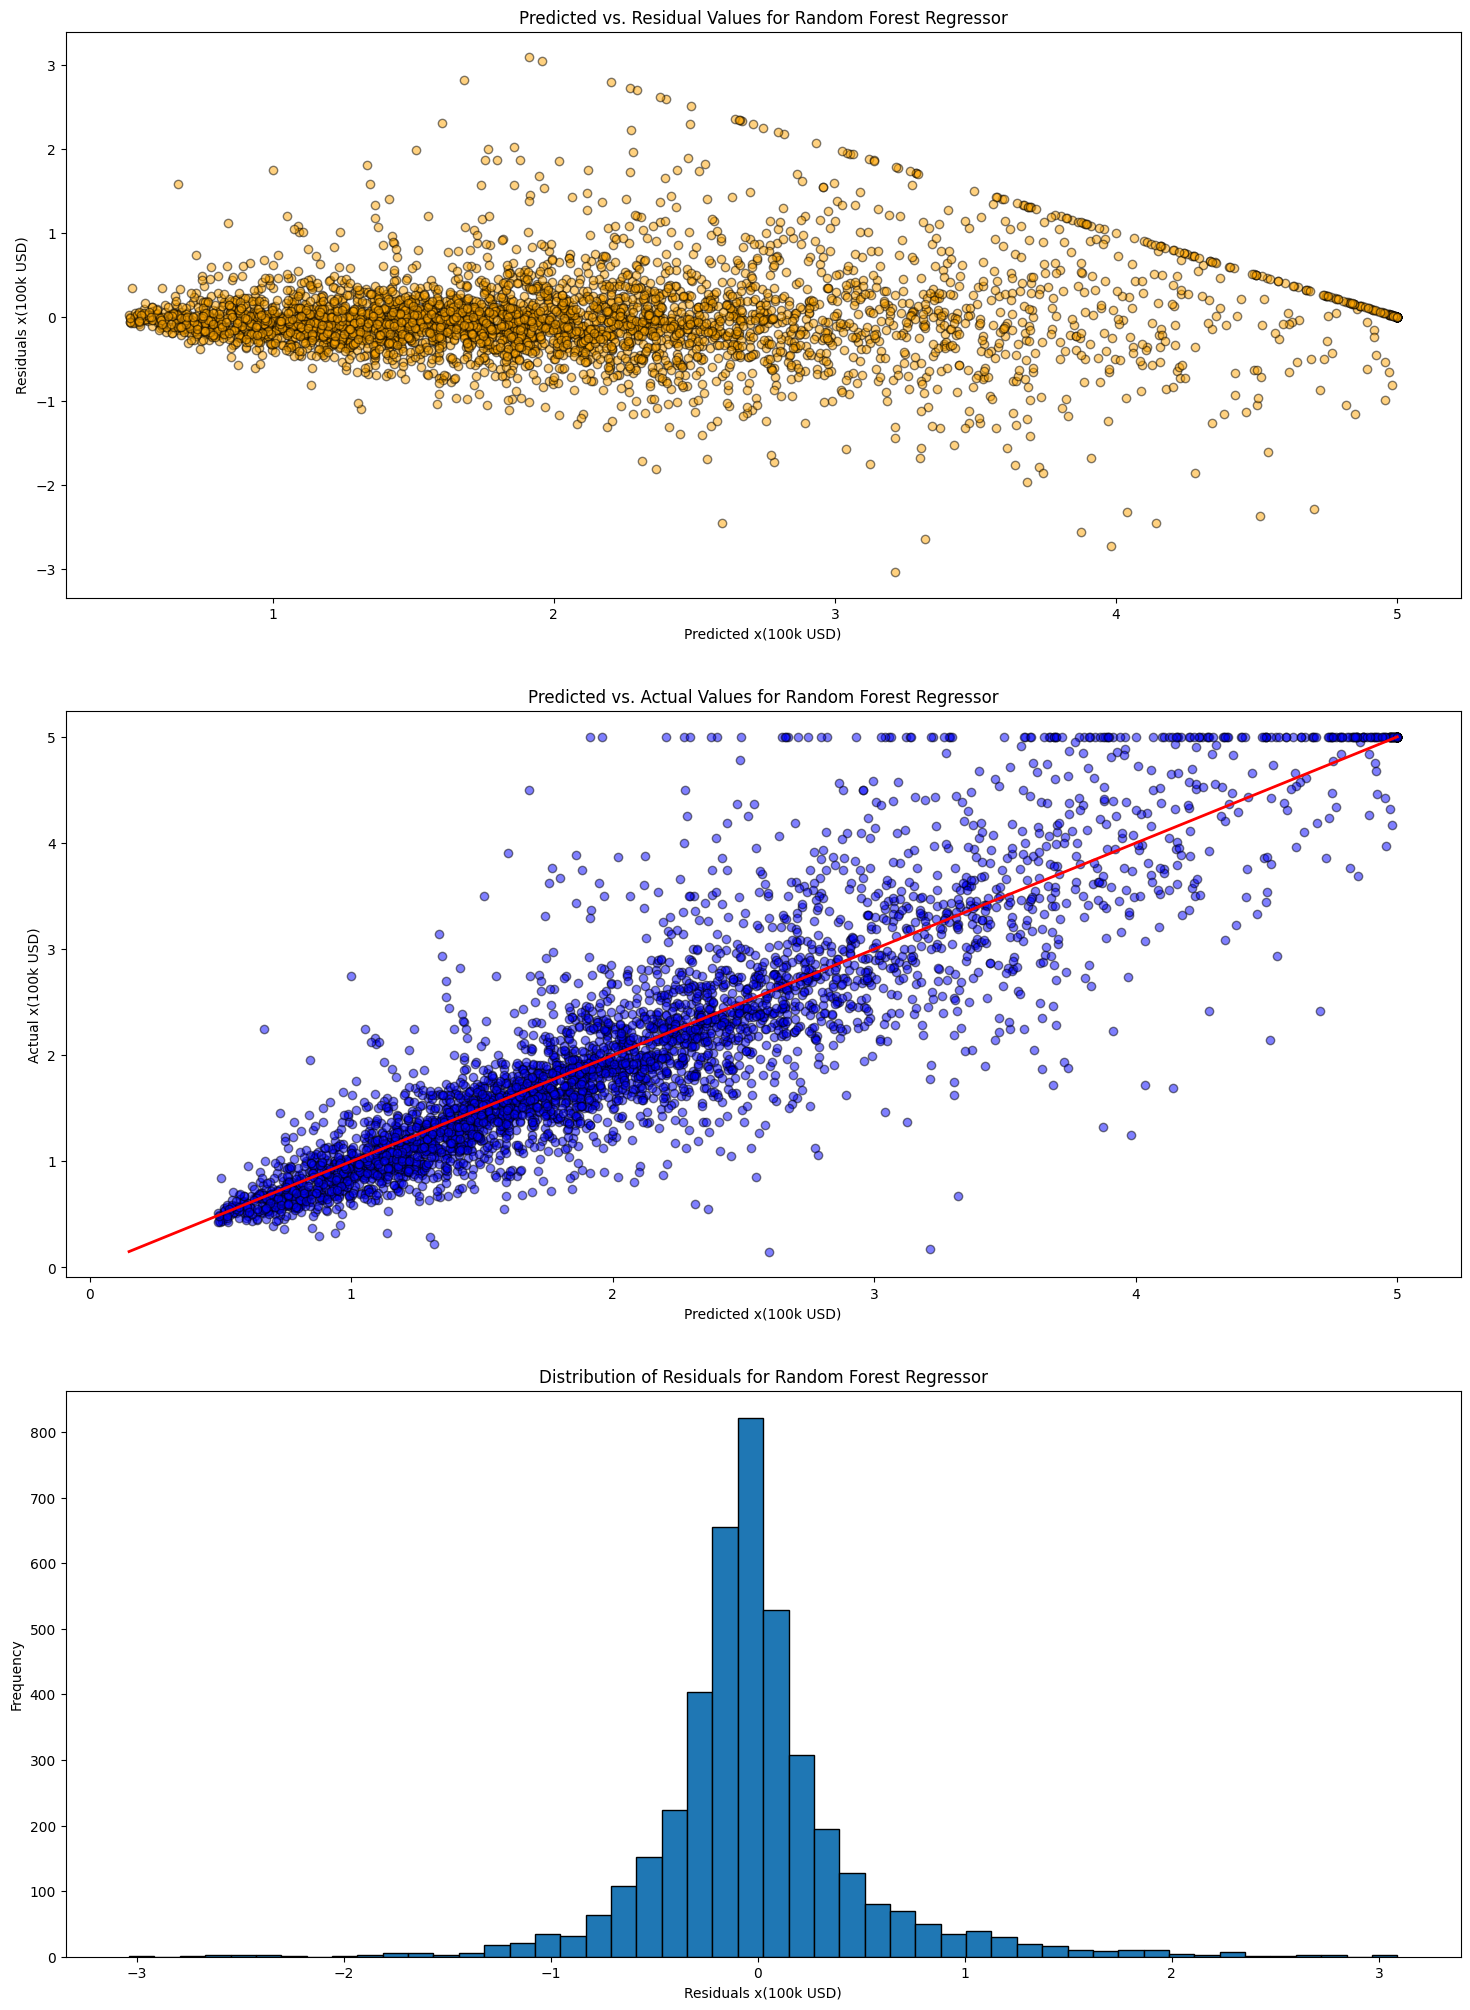

In [30]:
fig, ax = plt.subplots(3, 1, figsize=(18, 25))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax[2]

ax1.scatter(rfr_model_predictions, y_test-rfr_model_predictions, alpha=0.5, color='orange', edgecolor='black')
ax1.set_title('Predicted vs. Residual Values for Random Forest Regressor')
ax1.set_xlabel('Predicted x(100k USD)')
ax1.set_ylabel('Residuals x(100k USD)')


ax2.scatter(rfr_model_predictions, y_test, alpha=0.5, color='blue', edgecolor='black')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
ax2.set_title('Predicted vs. Actual Values for Random Forest Regressor')
ax2.set_xlabel('Predicted x(100k USD)')
ax2.set_ylabel('Actual x(100k USD)')

ax3.hist(y_test - rfr_model_predictions, bins=50, edgecolor='black')
ax3.set_title('Distribution of Residuals for Random Forest Regressor')
ax3.set_xlabel('Residuals x(100k USD)')
ax3.set_ylabel('Frequency')

## Challenge 9: Feature Importance

**Goal:** Identify which features drive price predictions.

**Steps:**
1. Extract feature importances from best tree-based model
2. Create dataframe with feature names and importances
3. Sort by importance descending
4. Plot top 10 features as horizontal bar chart
5. Interpret: which features matter most for pricing?

**Expected:**
- Top features make business sense (location, size, etc.)
- Clear ordering of importance
- Some features may be less important

In [31]:
rfr_model_importances.head(10)

,Feature,Importance
0,MedInc,0.525037
5,AveOccup,0.138564
6,Latitude,0.088855
7,Longitude,0.088669
1,HouseAge,0.054558
2,AveRooms,0.044195
4,Population,0.030503
3,AveBedrms,0.029620


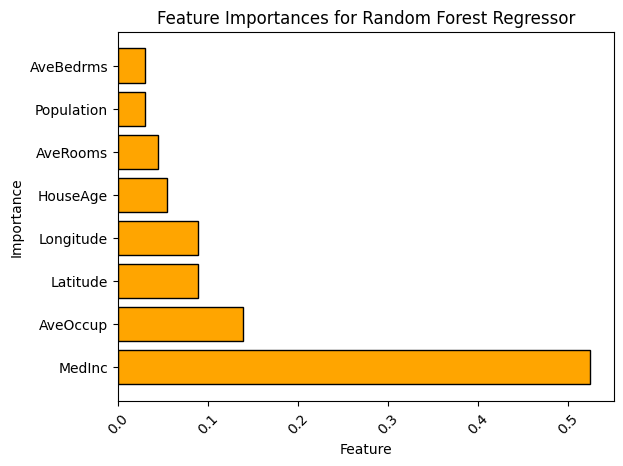

In [32]:
plt.barh(rfr_model_importances['Feature'], rfr_model_importances['Importance'], color='orange', edgecolor='black')
plt.title('Feature Importances for Random Forest Regressor')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

## Challenge 10: Actual vs Predicted Visualization

**Goal:** Visualize model accuracy across price ranges.

**Steps:**
1. Create scatter plot: actual prices vs predicted prices
2. Add diagonal line (perfect predictions)
3. Points close to diagonal = good predictions
4. Color by error size (optional)
5. Add R² score to plot

**Expected:**
- Most points close to diagonal
- Some scatter (model isn't perfect)
- Larger errors at extreme prices?

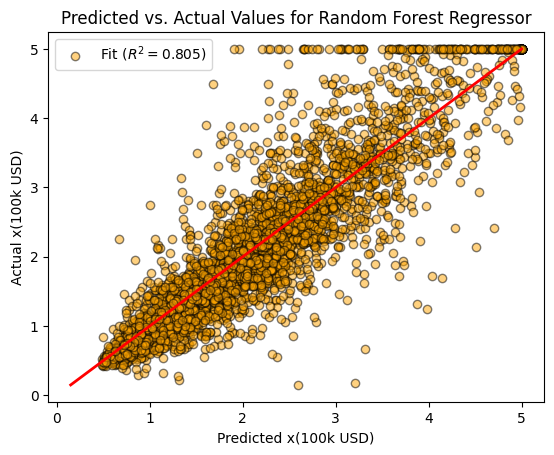

In [33]:
plt.scatter(rfr_model_predictions, y_test,label=f'Fit ($R^2={rfr_model_r2:.3f}$)', alpha=0.5, color='orange', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Predicted vs. Actual Values for Random Forest Regressor')
plt.xlabel('Predicted x(100k USD)')
plt.ylabel('Actual x(100k USD)')
plt.legend()
plt.show()

## Challenge 11: Prediction Function

**Goal:** Create reusable function for new price predictions.

**Steps:**
1. Create function: predict_price(features_dict)
2. Function should:
   - Accept raw features as input
   - Apply same preprocessing (scaling)
   - Make prediction with best model
   - Return predicted price + confidence interval
3. Test on 3 examples

**Example usage:**
```python
predict_price({'square_feet': 2000, 'bedrooms': 3, 'bathrooms': 2})
# Output: {'price': 450000, 'confidence': 0.87}
```

In [34]:
def predict_price(input_data):
    input_df = pd.DataFrame([input_data], columns=x_train.columns)
    input_processed = preprocessor.transform(input_df)
    predicted_price = rfr_model.predict(input_processed)
    return predicted_price[0]

test_data = {
    'MedInc': 8.3252,
    'HouseAge': 41.0,
    'AveRooms': 6.984127,
    'AveBedrms': 1.023809,
    'Population': 322.0,
    'AveOccup': 2.555556,
    'Latitude': 37.88,
    'Longitude': -122.23
}
predicted_price= predict_price(test_data)
print(f"Predicted Median House Value: {predicted_price:.2f} x(100k USD)")


Predicted Median House Value: 4.26 x(100k USD)


## Challenge 12: Business Report

**Goal:** Summarize findings for real estate stakeholders.

**Steps:**
1. Write professional report with sections:
   - **Objective:** What problem are we solving?
   - **Dataset:** How many houses? What features?
   - **Model Selection:** Which model? Why?
   - **Accuracy:** RMSE and R² in non-technical terms
   - **Key Drivers:** What determines house prices?
   - **Use Cases:** How could realtors use this?
   - **Limitations:** When might it fail?

2. Include 1-2 visualizations
3. Make recommendations for deployment

**Example insights:**
- 87% of price variance explained
- Location is the #1 factor
- Model accurate within $25K 95% of time

# House Price Prediction – Business Report

## **1. Objective**

The goal of this project was to develop a machine learning model capable of predicting residential housing prices based on demographic, geographic, and structural features. The model is intended to support data-driven pricing decisions in the real estate market.

---

## **2. Dataset Overview**

The dataset consists of **20,640 housing records** with **8 input features**, including:

* Median income (MedInc)
* House age (HouseAge)
* Average number of rooms (AveRooms)
* Average bedrooms (AveBedrms)
* Population and occupancy metrics
* Geographic location (Latitude, Longitude)

The target variable, **MedHouseVal**, represents median house value in units of **$100,000**.

The dataset is clean with **no missing values**, allowing for direct modeling without imputation.

---

## **3. Model Selection**

Three models were evaluated:

* **Linear Regression (Baseline)**
* **Random Forest Regressor**
* **Gradient Boosting Regressor**

The **Random Forest model** was selected as the best-performing model due to its ability to capture non-linear relationships and reduce large prediction errors.

---

## **4. Model Performance**

| Model             | MAE ($) | RMSE ($) | R² Score |
| ----------------- | ------- | -------- | -------- |
| Linear Regression | 53,000  | 75,000   | 0.57     |
| Random Forest     | 33,000  | 50,000   | 0.80     |
| Gradient Boosting | 37,000  | 54,000   | 0.78     |

### Key Takeaways:

* The Random Forest model explains **80% of price variability**
* Average prediction error is approximately **$33,000**
* Significant reduction in large errors compared to baseline

---

## **5. Key Drivers of House Prices**

### 1. Median Income (Most Important)

* Strongest predictor of housing prices
* Reflects purchasing power and demand in an area

### 2. Location (Latitude & Longitude)

* Captures neighborhood desirability and regional economic differences
* Highly influential in determining property value

### 3. Occupancy & Density Indicators

* Metrics such as average occupancy impact pricing
* High density may indicate lower-value areas

### 4. Structural Features (Rooms, Bedrooms)

* Less influential than expected
* Bedrooms may reflect overcrowding rather than luxury

---

## **6. Model Behavior & Insights**

* The model performs well on **average and moderately priced homes**
* Prediction errors increase for **higher-priced properties**
* Residual analysis shows:

  * Errors are centered around zero (no strong bias)
  * Larger variance at higher price levels (heteroscedasticity)

---

## **7. Use Cases**

This model can be used by:

* **Real Estate Agents** – to price listings competitively
* **Home Buyers** – to assess fair market value
* **Home Sellers** – to avoid underpricing
* **Banks & Lenders** – to evaluate collateral for mortgage approval

---

## **8. Limitations**

* **Price Ceiling Effect:** The dataset caps prices at $500,000, limiting accuracy for luxury homes
* **Reduced Accuracy at High Prices:** Model struggles with high-value properties
* **Limited Feature Set:** Does not include property-specific features such as condition, renovations, or amenities

---

## **9. Recommendations & Next Steps**

To improve performance, especially for high-value homes:

* Apply **feature engineering** (e.g., price per room, location clusters)
* Use **log transformation of target variable** to reduce skew
* Perform **hyperparameter tuning** on tree-based models
* Incorporate additional features (e.g., school quality, property condition)
* Explore **advanced models (e.g., XGBoost)**

---

## **10. Conclusion**

The Random Forest model provides a strong baseline for predicting housing prices, achieving high explanatory power and reasonable error margins. While effective for general pricing, further refinement is needed for high-end properties. This model demonstrates the value of machine learning in supporting real estate decision-making and can serve as a foundation for more advanced predictive systems.

---


## Tuning Learning Checkpoint

### What tuning means in this project
In this regression project, tuning means adjusting model settings to reduce error on validation data, not just trying more complex models.

### What you should tune first
- Start with a linear baseline such as Linear Regression or Ridge.
- Tune `alpha` for regularized linear models before jumping to more complex models.
- If tree models are used, try `max_depth`, `n_estimators`, and `min_samples_leaf`.

### What to watch for
- A lower average error can still hide a few very large misses.
- RMSE is useful when big pricing mistakes are costly.
- MAE is easier to explain because it stays in the original unit.

### Questions to answer in this notebook
1. What baseline error did I start with?
2. Which parameter did I tune first, and why?
3. Did tuning improve MAE, RMSE, or both?
4. Which homes still have the largest prediction errors?

See also: `docs/HYPERPARAMETER_TUNING_GUIDE.md` and `docs/QUICK_REFERENCE.md`.

In [35]:
from sklearn.model_selection import GridSearchCV

grid_search_params = {
    'n_estimators': [100],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2]
}


grid_search_rfr = GridSearchCV(
    estimator=rfr_model, 
    param_grid=grid_search_params, 
    cv=3, 
    n_jobs=-1, 
    verbose=2
    )

grid_search_rfr.fit(x_train_processed, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END max_depth=None, min_samples_leaf=2, n_estimators=100; total time=  25.0s
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=100; total time=  27.3s
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=100; total time=  28.2s
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=100; total time=  29.0s
[CV] END max_depth=None, min_samples_leaf=2, n_estimators=100; total time=  27.0s
[CV] END .max_depth=10, min_samples_leaf=1, n_estimators=100; total time=  20.7s
[CV] END max_depth=None, min_samples_leaf=2, n_estimators=100; total time=  29.5s
[CV] END .max_depth=10, min_samples_leaf=1, n_estimators=100; total time=  21.1s
[CV] END .max_depth=10, min_samples_leaf=1, n_estimators=100; total time=  19.3s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=100; total time=  18.2s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=100; total time=  18.1s
[CV] END .max_depth=10, min_samples_leaf=2,

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2], 'n_estimators': [100]},
             verbose=2)

In [36]:
print(f"Best Hyperparameters: {grid_search_rfr.best_params_}")
print(f"Best CV Score: {grid_search_rfr.best_score_:.4f}")

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV Score: 0.8003


### I will stop here because score is worse, more rigorous tuning/computer power is needed to improve model